# Emotion classification from text (BiLSTM)

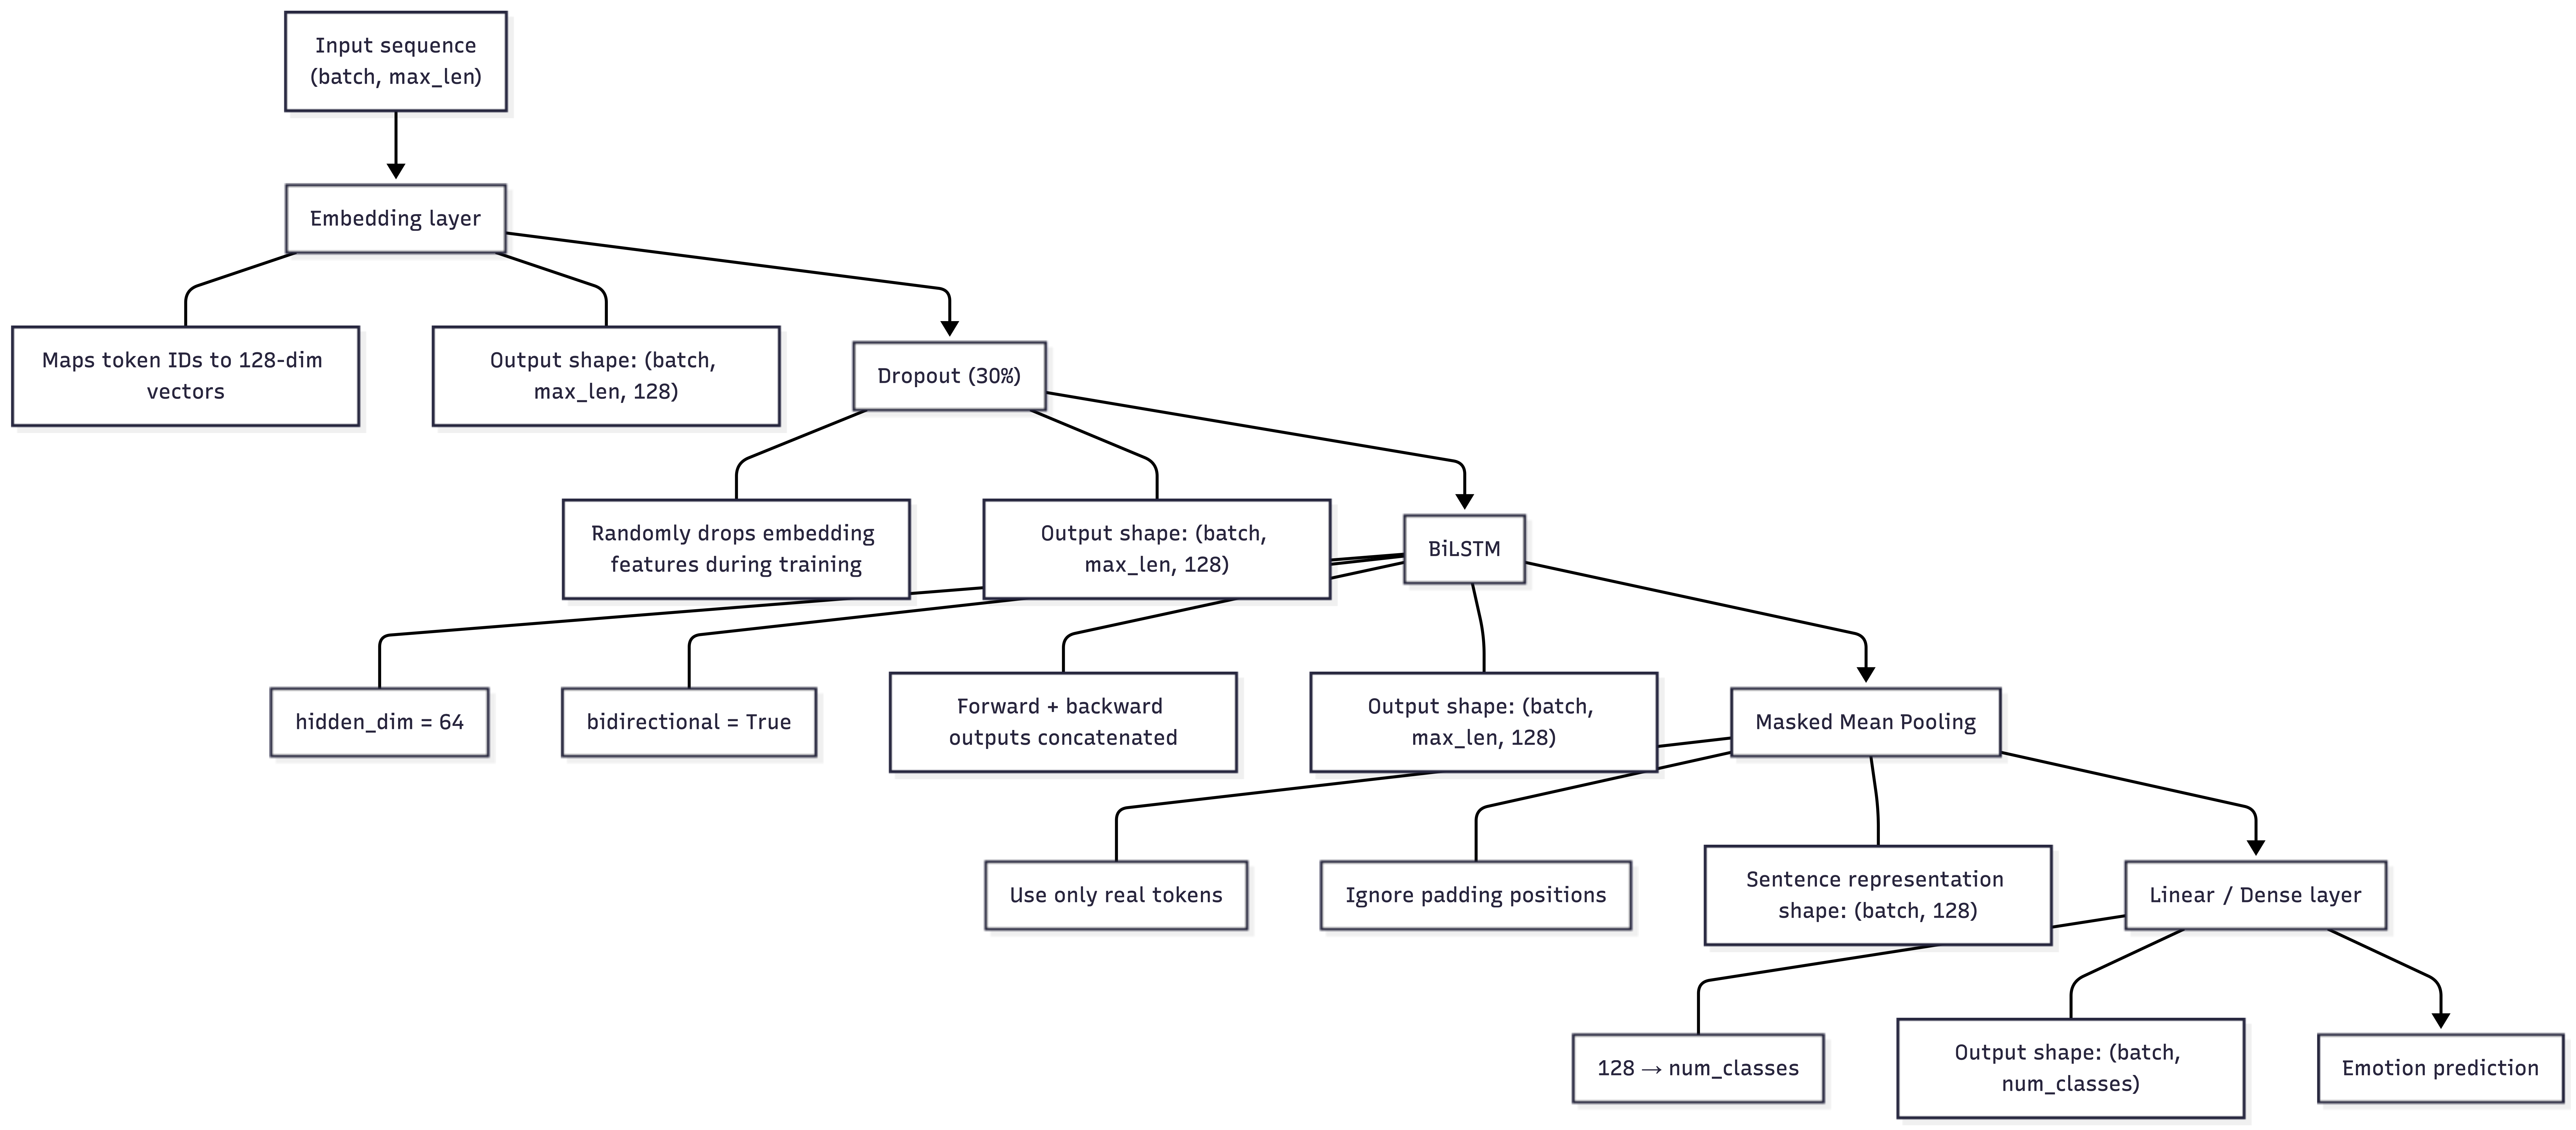

## 1. Setup

In [120]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [121]:
# Load dataset
raw = load_dataset("mteb/emotion")

## 2. EDA


Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger


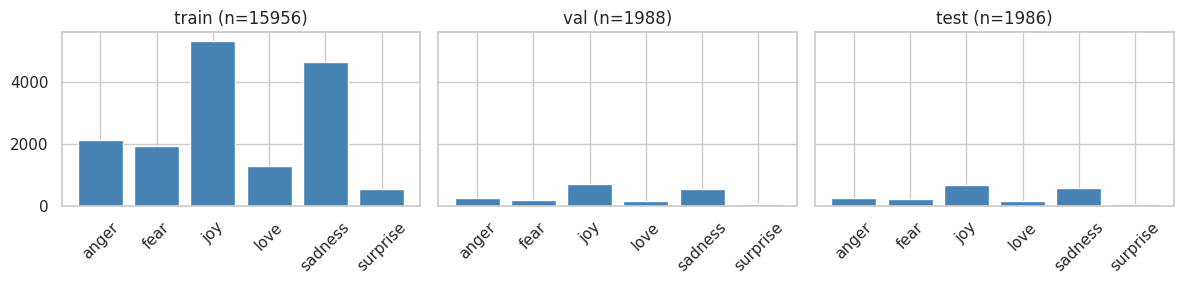


Random samples per class (train):

--- label=0 (sadness) ---
i sort of feel like one of those people who was unfortunate and lost their father when they were and life goes on
i wanted to write and feel purged of those repressed feelings
i have a neutral feeling about two broke girls because while i like kat denningss deadpan delivery and a href http media

--- label=1 (joy) ---
i cant help but feel as though perhaps my perception isnt as keen as i once thought
i feel honored to have that kind of support
i feel the determined nudge of the holy spirit to end my slumber and self love

--- label=2 (love) ---
i was like that i always wanted to feel and be accepted by my family and others
i feel a bit more loving energy inside connecting with you
i feel im being generous with that statement

--- label=3 (anger) ---
i was feeling frustrated at work wondering if i am living a life with meaning and purpose
i must say that the initial splash was not too bad but after a few strokes you could fee

In [122]:
# EDA
def hf_to_df(split_name):
    d = raw[split_name]
    return pd.DataFrame({"text": d["text"], "label": d["label"], "label_text": d["label_text"]})

train_df = hf_to_df("train")
val_df = hf_to_df("validation")
test_df = hf_to_df("test")

print("Columns:", list(train_df.columns))
print("\nRows — train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("\nFirst rows (train):")
display(train_df.head(3))


# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    vc = df["label_text"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_title(f"{name} (n={len(df)})")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


# Sample examples per class
print("\nRandom samples per class (train):")
for lab in sorted(train_df["label"].unique()):
    sub = train_df[train_df["label"] == lab]
    s = sub.sample(n=min(3, len(sub)), random_state=SEED)
    print(f"\n--- label={lab} ({s['label_text'].iloc[0]}) ---")
    for _, r in s.iterrows():
        print(r["text"][:200])


##3. Text preprocessing

In [123]:
def preprocess(text: str, lowercase: bool = True) -> str:
    t = str(text).strip()
    if lowercase:
        t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

# Preview
ex = train_df["text"].iloc[10]
print("Before:", ex)
print("After :", preprocess(ex))

Before: i feel like i have to make the suffering i m seeing mean something
After : i feel like i have to make the suffering i m seeing mean something


## 4. Label preparation

In [124]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label:", id2label)

num_classes: 6
id2label: {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


## 5. Split dataset


In [125]:
train_df["text_proc"] = train_df["text"].map(preprocess)
val_df["text_proc"] = val_df["text"].map(preprocess)
test_df["text_proc"] = test_df["text"].map(preprocess)

print("Split sizes:", len(train_df), len(val_df), len(test_df))

Split sizes: 15956 1988 1986


In [126]:
# Get sorted class ids, e.g. [0, 1, 2, 3, 4, 5]
classes = np.sort(train_df["label"].unique())

# Compute balanced class weights from training labels only
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy()
)

# Convert to torch tensor and move to device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:")

for c, w in zip(classes, class_weights.cpu().numpy()):
    print(f"  class {c} ({id2label[c]}): {w:.4f}")

Class weights:
  class 0 (sadness): 0.5703
  class 1 (joy): 0.4975
  class 2 (love): 2.0504
  class 3 (anger): 1.2357
  class 4 (fear): 1.3772
  class 5 (surprise): 4.6819


## 6. Vocabulary & sequences

In [127]:
# Special tokens
PAD, UNK = "<pad>", "<unk>"

# Only keep words that appear at least 2 times in the training set
min_freq = 2

def build_vocab(texts, min_freq=min_freq):
    """
    Build a word-to-id vocabulary from training texts only.

    Args:
        texts: iterable of processed text strings
        min_freq: minimum number of times a word must appear to be included in the vocabulary

    Returns:
        vocab: dict mapping token -> integer id
    """
    cnt = Counter()
    for t in texts:
        cnt.update(t.split())
    vocab = {PAD: 0, UNK: 1}
    for w, c in cnt.items():
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab

def texts_to_ids(texts, vocab, max_len):
    """
    Convert text strings into fixed-length sequences of token ids. Steps:
    1. Split each text into words
    2. Convert each word to its id using vocab - if word not found, use <unk> id
    3. Truncate sequence to max_len if too long
    4. Pad sequence with <pad> id if too short

    Args:
        texts: iterable of processed text strings
        vocab: token -> id dictionary
        max_len: fixed sequence length for all samples

    Returns:
        np.array of shape (num_samples, max_len)
    """
    pad_id, unk_id = vocab[PAD], vocab[UNK]
    rows = []
    for t in texts:
        ids = [vocab.get(w, unk_id) for w in t.split()][:max_len]
        pad_len = max_len - len(ids)
        ids = ids + [pad_id] * pad_len
        rows.append(ids)
    return np.array(rows, dtype=np.int64)

# Choose max_len from train word-length percentiles (~95% coverage)
_wc = train_df["text_proc"].map(lambda s: len(s.split()))
max_len = int(np.clip(_wc.quantile(0.95), 16, 128))
print("Chosen max_len (95p train word count, clipped 16–128):", max_len)

# Build vocab only on the training set to avoid data leakage
vocab = build_vocab(train_df["text_proc"], min_freq=min_freq)
vocab_size = len(vocab)
print("vocab_size:", vocab_size)

# Convert text data into padded token-id sequences
X_train = texts_to_ids(train_df["text_proc"], vocab, max_len)
X_val = texts_to_ids(val_df["text_proc"], vocab, max_len)
X_test = texts_to_ids(test_df["text_proc"], vocab, max_len)
y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Chosen max_len (95p train word count, clipped 16–128): 41
vocab_size: 7386
Shapes: (15956, 41) (1988, 41) (1986, 41)


In [128]:
sample_text = train_df["text_proc"].iloc[69]
sample_ids = texts_to_ids([sample_text], vocab, max_len)[0]

print("Original text:")
print(sample_text)

print("\nWords:")
print(sample_text.split())

print("\nToken IDs:")
print(sample_ids)

print("\nLength after padding/truncation:")
print(len(sample_ids))

Original text:
i was feeling brave when i bought it and clearly when i was doing my makeup

Words:
['i', 'was', 'feeling', 'brave', 'when', 'i', 'bought', 'it', 'and', 'clearly', 'when', 'i', 'was', 'doing', 'my', 'makeup']

Token IDs:
[  2  53   9 358 229   2 544  40  21 545 229   2  53 164 174 546   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0]

Length after padding/truncation:
41


## 7. PyTorch Dataset / DataLoader

In [129]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, batch_size, shuffle):
    ds = EmotionDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 64
train_loader = make_loader(X_train, y_train, BATCH_SIZE, True)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, False)


## 8. BiLSTM model

In [130]:
# BiLSTM model for text emotion classification
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,          # total number of tokens in vocabulary
        embed_dim,           # size of each word embedding vector
        hidden_dim,          # hidden size of LSTM
        num_classes,         # number of emotion classes
        padding_idx,         # token id used for <pad>
        num_layers=1,        # number of stacked LSTM layers
        bidirectional=True,  # use BiLSTM if True, normal LSTM if False
        dropout=0.3,         # dropout rate
    ):
        super().__init__()

        # Save padding id so we can ignore padded positions later
        self.padding_idx = padding_idx

        # Embedding layer:
        # input: token ids of shape (B, T)
        # output: dense vectors of shape (B, T, embed_dim)
        # padding_idx tells PyTorch which token is padding
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)

        # Dropout applied to embeddings to reduce overfitting

        self.dropout = nn.Dropout(dropout)

        # LSTM layer:
        # input shape:  (B, T, embed_dim)
        # output shape: (B, T, hidden_dim * num_directions)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,   # input/output shape uses batch first: (B, T, D)
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Output dimension of LSTM:
        # if bidirectional=True, output size doubles (forward + backward)
        h_out = hidden_dim * (2 if bidirectional else 1)

        # Final classifier layer:
        # maps pooled sentence representation -> class logits
        self.fc = nn.Linear(h_out, num_classes)


    # Forward pass shape flow:
    # x            : (B, T)                  -> batch of token IDs
    # embed(x)     : (B, T, embed_dim)       -> word embeddings
    # lstm(emb)    : (B, T, h_out)           -> contextual outputs for each time step
    # mask         : (B, T, 1)               -> 1 for real tokens, 0 for padding
    # summed       : (B, h_out)              -> sum of valid time-step outputs
    # lengths      : (B, 1)                  -> number of valid tokens per sequence
    # pooled       : (B, h_out)              -> masked mean-pooled sentence representation
    # fc(pooled)   : (B, num_classes)        -> class logits
    def forward(self, x):
        # x shape: (B, T)
        # B = batch size, T = sequence length
        # Convert token ids to embeddings, then apply dropout
        # emb shape: (B, T, embed_dim)
        emb = self.dropout(self.embed(x))

        # Pass embeddings through LSTM
        # out shape: (B, T, h_out)
        out, _ = self.lstm(emb)

        # Create mask to identify real tokens (not padding)
        # shape: (B, T), True for real words, False for <pad>
        mask = x != self.padding_idx

        # Expand mask shape to match LSTM output for multiplication
        # shape becomes: (B, T, 1)
        # convert to float so True -> 1.0, False -> 0.0
        mask = mask.unsqueeze(-1).float()

        # Zero out padded positions and sum over time dimension
        # summed shape: (B, h_out)
        summed = (out * mask).sum(dim=1)

        # Count number of real tokens in each sequence
        # lengths shape: (B, 1)
        # clamp(min=1.0) avoids division by zero
        lengths = mask.sum(dim=1).clamp(min=1.0)

        # Mean pooling over only real tokens
        # pooled shape: (B, h_out)
        pooled = summed / lengths

        # Final class scores (logits)
        # output shape: (B, num_classes)
        return self.fc(pooled)


# Count trainable parameters in the model
def count_params(m):
    # Count number of parameters that will actually be updated during training
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

pad_id = vocab[PAD]
model_demo = BiLSTMClassifier(vocab_size, 128, 64, num_classes, pad_id).to(device)
print("Trainable params (demo config):", count_params(model_demo))

Trainable params (demo config): 1045510


In [131]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, criterion):
    # Set model to training mode
    # This enables dropout and other training-specific behavior
    model.train()
    total_loss = 0.0

    # Loop through batches from DataLoader
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        # Forward pass: compute predicted logits
        logits = model(xb)

        # Compute loss between prediction and true labels
        loss = criterion(logits, yb)

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        # Useful for RNN/LSTM training stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model parameters
        optimizer.step()

        # Accumulate total loss weighted by batch size
        total_loss += loss.item() * xb.size(0)

    # Return average loss over the whole dataset
    return total_loss / len(loader.dataset)


# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion=None):
    # Set model to evaluation mode - disables dropout
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        # Forward pass
        logits = model(xb)

        # Compute loss only if criterion is provided
        if criterion is not None:
            total_loss += criterion(logits, yb).item() * xb.size(0)

        # Predicted class = index of highest logit
        all_p.append(logits.argmax(dim=-1).cpu().numpy())

        # Store true labels
        all_y.append(yb.cpu().numpy())

    # Merge all batches into full arrays
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    # Compute evaluation metrics
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),

    }

    # Add average loss if criterion was used
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred

## 9. Training - CrossEntropyLoss, Adam, early stopping on val macro-F1

In [132]:
# Training loop flow:
# 1. Train model for one epoch on train_loader
#    - forward pass
#    - compute loss
#    - backpropagation
#    - gradient clipping
#    - optimizer step
# 2. Evaluate model on val_loader
#    - compute validation loss
#    - compute accuracy / macro-F1 / weighted-F1
# 3. Save metrics into history
#    - train_loss
#    - val_loss
#    - val_macro_f1
#    - val_acc
# 4. Check if validation macro-F1 improved
#    - if improved: save best model state and reset patience counter
#    - if not improved: increase stale counter
# 5. Apply early stopping
#    - stop training if no improvement for 'patience' epochs
# 6. Restore best model weights before returning

# Training loop with validation and early stopping
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-3,
    weight_decay=1e-5,
    patience=3,   # stop if validation macro-F1 does not improve for this many epochs
    class_weights=None,
):
    # CrossEntropyLoss is standard for multi-class classification
    criterion = nn.CrossEntropyLoss() if class_weights is None else nn.CrossEntropyLoss(weight=class_weights)

    # Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Store training history for plotting later
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_acc": []}

    # Track best model according to validation macro-F1
    best_state = None
    best_f1 = -1.0
    stale = 0  # number of epochs without improvement

    for ep in range(1, epochs + 1):
        # Train one epoch
        tl = train_one_epoch(model, train_loader, optimizer, criterion)

        # Evaluate on validation set
        vm, _, _ = evaluate(model, val_loader, criterion)

        # Save current metrics
        history["train_loss"].append(tl)
        history["val_loss"].append(vm["loss"])
        history["val_macro_f1"].append(vm["macro_f1"])
        history["val_acc"].append(vm["acc"])

        # Check whether validation macro-F1 improved
        if vm["macro_f1"] > best_f1 + 1e-5:
            best_f1 = vm["macro_f1"]

            # Save a copy of the best model weights
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        # Print progress occasionally
        if ep == 1 or ep % 2 == 0 or stale == 0:
            print(
                f"Epoch {ep:02d} "
                f"train_loss={tl:.4f} "
                f"val_loss={vm['loss']:.4f} "
                f"val_acc={vm['acc']:.4f} "
                f"val_macro_f1={vm['macro_f1']:.4f}"
            )

        # Stop early if no improvement for 'patience' epochs
        if stale >= patience:
            print(
                f"Early stopping at epoch {ep} "
                f"(no val macro-F1 improvement for {patience} epochs)."
            )
            break

    # Restore best model weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_f1

# Plot training curves
def plot_history(history, title="Training"):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))

    # Plot train/validation loss
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()

    # Plot validation metrics
    ax[1].plot(history["val_macro_f1"], label="val macro-F1")
    ax[1].plot(history["val_acc"], label="val acc", alpha=0.6)
    ax[1].set_title("Val metrics")
    ax[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## 10. Train BiLSTM

### Train BiLSTM without Class Weights

Epoch 01 train_loss=1.5415 val_loss=1.4026 val_acc=0.4683 val_macro_f1=0.2229
Epoch 02 train_loss=1.1960 val_loss=0.8562 val_acc=0.6881 val_macro_f1=0.4756
Epoch 03 train_loss=0.7818 val_loss=0.5328 val_acc=0.8194 val_macro_f1=0.7215
Epoch 04 train_loss=0.5302 val_loss=0.4039 val_acc=0.8612 val_macro_f1=0.8165
Epoch 05 train_loss=0.3791 val_loss=0.3074 val_acc=0.8883 val_macro_f1=0.8558
Epoch 06 train_loss=0.2868 val_loss=0.2669 val_acc=0.9095 val_macro_f1=0.8793
Epoch 07 train_loss=0.2264 val_loss=0.2296 val_acc=0.9195 val_macro_f1=0.8921
Epoch 08 train_loss=0.1877 val_loss=0.2332 val_acc=0.9160 val_macro_f1=0.8911
Epoch 09 train_loss=0.1605 val_loss=0.1977 val_acc=0.9266 val_macro_f1=0.9011
Epoch 10 train_loss=0.1305 val_loss=0.2073 val_acc=0.9281 val_macro_f1=0.9035
Epoch 11 train_loss=0.1187 val_loss=0.2072 val_acc=0.9276 val_macro_f1=0.9035
Epoch 12 train_loss=0.1037 val_loss=0.1952 val_acc=0.9321 val_macro_f1=0.9105
Epoch 14 train_loss=0.0800 val_loss=0.2012 val_acc=0.9296 val_ma

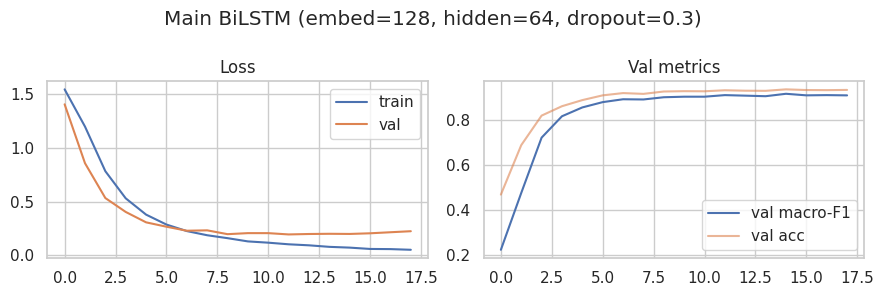

In [133]:
# Set random seed for reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Create the BiLSTM model with the selected hyperparameters
main_model = BiLSTMClassifier(
    vocab_size,
    embed_dim=128,
    hidden_dim=64,
    num_classes=num_classes,
    padding_idx=pad_id,
    bidirectional=True,
    dropout=0.3,
).to(device)

# Train the model using the training set and validate on the validation set
hist_main, best_val_f1 = train_model(
    main_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=1e-3,
    patience=3,
    class_weights=None
  )

print("Best val macro-F1 (main):", best_val_f1)
plot_history(hist_main, title="Main BiLSTM (embed=128, hidden=64, dropout=0.3)")

### Train BiLSTM with Class Weights

Epoch 01 train_loss=1.7250 val_loss=1.4701 val_acc=0.3551 val_macro_f1=0.3499
Epoch 02 train_loss=1.2505 val_loss=0.8667 val_acc=0.6222 val_macro_f1=0.6365
Epoch 03 train_loss=0.8333 val_loss=0.5376 val_acc=0.7953 val_macro_f1=0.7860
Epoch 04 train_loss=0.5838 val_loss=0.3929 val_acc=0.8546 val_macro_f1=0.8406
Epoch 05 train_loss=0.4307 val_loss=0.3225 val_acc=0.8818 val_macro_f1=0.8647
Epoch 06 train_loss=0.3225 val_loss=0.2764 val_acc=0.8954 val_macro_f1=0.8760
Epoch 07 train_loss=0.2599 val_loss=0.2440 val_acc=0.9074 val_macro_f1=0.8860
Epoch 08 train_loss=0.2175 val_loss=0.2482 val_acc=0.9160 val_macro_f1=0.8961
Epoch 09 train_loss=0.1854 val_loss=0.2112 val_acc=0.9195 val_macro_f1=0.8980
Epoch 10 train_loss=0.1523 val_loss=0.2036 val_acc=0.9215 val_macro_f1=0.9006
Epoch 11 train_loss=0.1380 val_loss=0.2143 val_acc=0.9235 val_macro_f1=0.9010
Epoch 12 train_loss=0.1180 val_loss=0.2099 val_acc=0.9311 val_macro_f1=0.9133
Epoch 14 train_loss=0.0983 val_loss=0.2130 val_acc=0.9306 val_ma

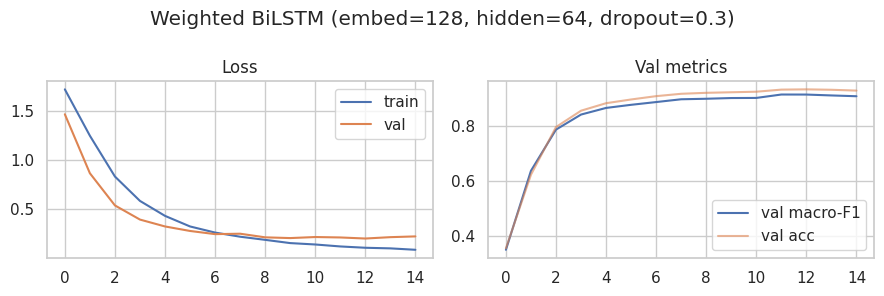

In [134]:
# Set random seed for reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Create the BiLSTM model with the selected hyperparameters and class weights
weighted_model = BiLSTMClassifier(
    vocab_size,
    embed_dim=128,
    hidden_dim=64,
    num_classes=num_classes,
    padding_idx=pad_id,
    bidirectional=True,
    dropout=0.3,
).to(device)

# Train the model using the training set and validate on the validation set, applying class weights
hist_weighted, best_val_f1_weighted = train_model(
    weighted_model,
    train_loader,
    val_loader,
    epochs=25,
    lr=1e-3,
    patience=3,
    class_weights=class_weights
)

print("Best val macro-F1 (weighted):".format(best_val_f1_weighted))
plot_history(hist_weighted, title="Weighted BiLSTM (embed=128, hidden=64, dropout=0.3)")

## 11. Evaluation

In [135]:
def full_report(y_true, y_pred, split_name="val"):
    """
    Print a full classification report and plot the confusion matrix.

    Args:
        y_true: true labels
        y_pred: predicted labels
        split_name: name of the data split, e.g. 'validation' or 'test'

    Returns:
        cm: confusion matrix as a NumPy array
    """

    # Create class names in label-id order
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Print split name
    print(f"=== {split_name} ===")

    # Print overall accuracy
    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Compute per-class precision, recall, and F1
    # average=None means return metric for each class separately
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys())
    )

    # Print metrics for each class
    print("\nPer-class precision/recall/F1:")
    for i, lab in enumerate(sorted(id2label.keys())):
        print(f"  {names[i]:10s}  P={p[i]:.3f}  R={r[i]:.3f}  F1={f1[i]:.3f}")

    # Print macro-F1 and weighted-F1
    print(
        "\nMacro / weighted F1:",
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted")

    )

    # Print sklearn's detailed classification report
    print("\n", classification_report(y_true, y_pred, target_names=names, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,         # show numbers inside cells
        fmt="d",            # integer format
        cmap="Blues",
        xticklabels=names,
        yticklabels=names
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return cm

=== Test BiLSTM (without class weights) ===
Accuracy: 0.9361167002012073

Per-class precision/recall/F1:
  sadness     P=0.960  R=0.951  F1=0.955
  joy         P=0.945  R=0.956  F1=0.950
  love        P=0.878  R=0.913  F1=0.895
  anger       P=0.928  R=0.945  F1=0.937
  fear        P=0.948  R=0.858  F1=0.900
  surprise    P=0.835  R=0.887  F1=0.861

Macro / weighted F1: 0.9164219670403843 0.9360993635992396

               precision    recall  f1-score   support

     sadness      0.960     0.951     0.955       550
         joy      0.945     0.956     0.950       700
        love      0.878     0.913     0.895       173
       anger      0.928     0.945     0.937       274
        fear      0.948     0.858     0.900       211
    surprise      0.835     0.887     0.861        80

    accuracy                          0.936      1988
   macro avg      0.916     0.918     0.916      1988
weighted avg      0.937     0.936     0.936      1988



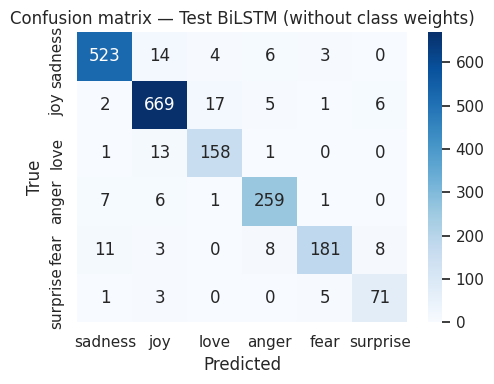

array([[523,  14,   4,   6,   3,   0],
       [  2, 669,  17,   5,   1,   6],
       [  1,  13, 158,   1,   0,   0],
       [  7,   6,   1, 259,   1,   0],
       [ 11,   3,   0,   8, 181,   8],
       [  1,   3,   0,   0,   5,  71]])

In [136]:
# Evaluate the main_model (without class weights) on the val set
_, yt_t_main, yt_p_main = evaluate(main_model, val_loader, nn.CrossEntropyLoss())
full_report(yt_t_main, yt_p_main, "Test BiLSTM (without class weights)")

=== Test BiLSTM (with class weights) ===
Accuracy: 0.9310865191146881

Per-class precision/recall/F1:
  sadness     P=0.966  R=0.933  F1=0.949
  joy         P=0.965  R=0.933  F1=0.948
  love        P=0.828  R=0.977  F1=0.897
  anger       P=0.903  R=0.953  F1=0.927
  fear        P=0.923  R=0.853  F1=0.887
  surprise    P=0.815  R=0.938  F1=0.872

Macro / weighted F1: 0.9133466528798921 0.9315565205813765

               precision    recall  f1-score   support

     sadness      0.966     0.933     0.949       550
         joy      0.965     0.933     0.948       700
        love      0.828     0.977     0.897       173
       anger      0.903     0.953     0.927       274
        fear      0.923     0.853     0.887       211
    surprise      0.815     0.938     0.872        80

    accuracy                          0.931      1988
   macro avg      0.900     0.931     0.913      1988
weighted avg      0.934     0.931     0.932      1988



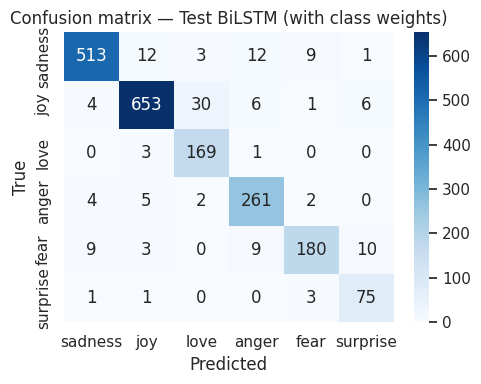

array([[513,  12,   3,  12,   9,   1],
       [  4, 653,  30,   6,   1,   6],
       [  0,   3, 169,   1,   0,   0],
       [  4,   5,   2, 261,   2,   0],
       [  9,   3,   0,   9, 180,  10],
       [  1,   1,   0,   0,   3,  75]])

In [137]:
# Evaluate the weighted_model (with class weights) on the val set
_, yt_t_weighted, yt_p_weighted = evaluate(weighted_model, val_loader, nn.CrossEntropyLoss())
full_report(yt_t_weighted, yt_p_weighted, "Test BiLSTM (with class weights)")

## 12. Error analysis


In [138]:
def analyze_errors(model, loader, id2label, split_name, seed=SEED):
    """
    Performs error analysis on a given model and data loader.

    Args:
        model: The trained model.
        loader: DataLoader for the dataset (e.g., validation set).
        id2label: Dictionary mapping label IDs to text labels.
        split_name: Name of the data split (e.g., 'Validation').
        seed: Random seed for sampling errors.
    """
    print(f"\n--- Error Analysis for {split_name} ---")

    # Run evaluation on the validation set
    _, y_true, y_pred = evaluate(model, loader, None)

    # Create ordered class names from label ids
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    # Find the most common confusion pairs
    pairs = []
    n = cm.shape[0]
    for i in range(n):
        for j in range(n):
            if i != j and cm[i, j] > 0:
                pairs.append((cm[i, j], names[i], names[j]))
    pairs.sort(reverse=True)

    # Print the most frequent confusion types
    print("Top confused (true -> pred):")
    for c, a, b in pairs[:8]:
        print(f"  {c:4d}  {a} -> {b}")

    # Show some actual misclassified validation examples
    # Assuming `val_df` is available in the global scope
    val_texts = val_df["text_proc"].to_numpy()
    wrong_idx = np.where(y_true != y_pred)[0]
    sample = np.random.default_rng(seed).choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
    print("\nSample errors (val):")
    for i in sample:
        print(f"\n true={names[y_true[i]]} pred={names[y_pred[i]]}")
        print(" ", val_texts[i][:280])

# Analyze errors for the main_model (without class weights)
analyze_errors(main_model, val_loader, id2label, "Main BiLSTM (without weights)")



--- Error Analysis for Main BiLSTM (without weights) ---
Top confused (true -> pred):
    17  joy -> love
    14  sadness -> joy
    13  love -> joy
    11  fear -> sadness
     8  fear -> surprise
     8  fear -> anger
     7  anger -> sadness
     6  sadness -> anger

Sample errors (val):

 true=love pred=joy
  im feeling generous ill show you when its done

 true=fear pred=sadness
  i so desperately want to be able to help but i feel so helpless

 true=fear pred=surprise
  i feel like they think i hate them or something and its just weird

 true=fear pred=sadness
  i don t know i feel really helpless about it

 true=fear pred=sadness
  that day i was alone at home after coming home from school i did not know where everyone else had gone

 true=fear pred=anger
  i feeling soo agitated

 true=sadness pred=joy
  talking to a very good friend who had just had a very bad experience which was changing his whole way of looking at life etc

 true=love pred=joy
  i didn t consider that she 

In [139]:
analyze_errors(weighted_model, val_loader, id2label, "Weighted BiLSTM (with weights)")


--- Error Analysis for Weighted BiLSTM (with weights) ---
Top confused (true -> pred):
    30  joy -> love
    12  sadness -> joy
    12  sadness -> anger
    10  fear -> surprise
     9  sadness -> fear
     9  fear -> sadness
     9  fear -> anger
     6  joy -> surprise

Sample errors (val):

 true=fear pred=sadness
  i feel so helpless when i look out at the world

 true=surprise pred=joy
  i as representative of everything thats wrong with corporate america and feel that sending him to washington is a ludicrous idea

 true=fear pred=sadness
  when i was walking around all alone at night

 true=anger pred=sadness
  someone acting stupid in public

 true=joy pred=love
  i am still setting myself the challenge of painting roses in a way that i feel i am capturing their beauty and sweet perfume

 true=fear pred=anger
  i feeling soo agitated

 true=fear pred=anger
  i was sleeping when i heard the neighbours screaming

 true=fear pred=joy
  i feel for the author but i m also hesitant